## Construcción de grafo usuario-producto. Calcular densidad, diámetro inicial. 

In [1]:
# !pip install pandas tqdm

## 1. Importaciones

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import time
import pandas as pd
import json
from implementaciones.preprocessing import load_reviews_efficiently
from implementaciones.graphs import BipartiteGraph

## 2. Configuración de Rutas de Datos
Definimos la ruta del archivo JSON de reseñas de Yelp extraído localmente en la carpeta `Yelp-JSON`.

In [4]:
REVIEW_PATH = 'Yelp-JSON/Yelp JSON/yelp_academic_dataset_review.json'

## 3. Carga Eficiente de Datos con Muestreo
Para evitar el desbordamiento de memoria al leer el archivo completo de 5.34 GB, leemos las primeras 300,001 reseñas (emulando el tamaño del sample previo del EDA) y luego seleccionamos una muestra aleatoria de 100,000 registros.

In [5]:
print("Cargando dataset de reseñas...")
df_temp = load_reviews_efficiently(REVIEW_PATH, sample_size=300001, use_reservoir=True)
print(f"Filas leídas: {len(df_temp)}")

print("Seleccionando una muestra aleatoria de 300,000 reseñas...")
sample_df = df_temp.sample(min(100000, len(df_temp)), random_state=42)
print(f"Muestra final lista: {len(sample_df)}")
sample_df.head()

Cargando dataset de reseñas...


Reservoir Sampling de reseñas: 0it [00:00, ?it/s]

Reservoir Sampling de reseñas: 6990280it [00:24, 279821.89it/s] 


Filas leídas: 299675
Seleccionando una muestra aleatoria de 300,000 reseñas...
Muestra final lista: 100000


,user_id,business_id,stars
86799,mK4gA84dV7jhG_Ll0mWGfQ,ujYhU3bX35BCVj1NUbSQpQ,4.0
45450,Cn9yKXkcSFkceC0_ocRrCQ,rB067lnTKVSiMU46z24BHg,5.0
1708,w58CkWaOVf-D7OYM0fN4BQ,ttD2S10kzZY24yLEq3I3Sg,5.0
272822,Zsucq1c-sjuGxs5jZuUEEg,9wjPUaB9HdaKkh5jaz964g,4.0
207884,FpMu6MaWpGJv8BW_cYENkA,0qu0fNTOsSmuREYVIMPuIQ,4.0


1. Calculando distribución real en el dataset completo (vía streaming para no agotar RAM)...
2. Calculando distribución en la muestra...

--- TABLA DE COMPARACIÓN ---
     Población (Completo) %  Muestra %  Diferencia Absoluta %
1.0                 15.3007     15.446                 0.1453
2.0                  7.7857      7.768                 0.0177
3.0                  9.8985      9.839                 0.0595
4.0                 20.7848     20.593                 0.1918
5.0                 46.2303     46.354                 0.1237


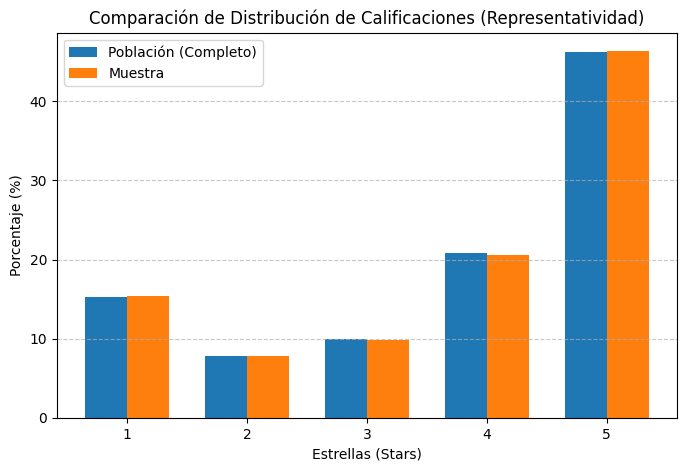

In [6]:
import json                                                                                                                                                                                                         
from collections import Counter                                                                                                                                                                                     
import pandas as pd                                                                                                                                                                                                 
import numpy as np                                                                                                                                                                                                  
import matplotlib.pyplot as plt                                                                                                                                                                                     
from scipy.stats import chisquare                                                                                                                                                                                   
                                                                                                                                                                                                                    
print("1. Calculando distribución real en el dataset completo (vía streaming para no agotar RAM)...")                                                                                                               
pop_stars_counts = Counter()                                                                                                                                                                                        
total_population = 0                                                                                                                                                                                                
                                                                                                                                                                                                                    
# Leemos el archivo línea por línea sin cargarlo todo a la vez                                                                                                                                                      
with open(REVIEW_PATH, 'r', encoding='utf-8') as f:                                                                                                                                                                 
    for line in f:                                                                                                                                                                                                  
        # Cargamos solo la clave 'stars'                                                                                                                                                                            
        # Nota: Si ujson está disponible, puedes usar ujson.loads para mayor velocidad                                                                                                                              
        obj = json.loads(line)                                                                                                                                                                                      
        pop_stars_counts[obj['stars']] += 1                                                                                                                                                                         
        total_population += 1                                                                                                                                                                                       
                                                                                                                                                                                                                    
# Convertir a proporciones (porcentajes)                                                                                                                                                                            
pop_dist = {star: count / total_population for star, count in pop_stars_counts.items()}                                                                                                                             
pop_dist = dict(sorted(pop_dist.items()))                                                                                                                                                                           
                                                                                                                                                                                                                    
print("2. Calculando distribución en la muestra...")                                                                                                                                                                
sample_stars_counts = sample_df['stars'].value_counts()                                                                                                                                                             
total_sample = len(sample_df)                                                                                                                                                                                       
sample_dist = {star: count / total_sample for star, count in sample_stars_counts.items()}                                                                                                                           
sample_dist = dict(sorted(sample_dist.items()))                                                                                                                                                                     
                                                                                                                                                                                                                    
# 3. Crear DataFrame de comparación                                                                                                                                                                                 
df_compare = pd.DataFrame({                                                                                                                                                                                         
    'Población (Completo) %': {k: v * 100 for k, v in pop_dist.items()},                                                                                                                                            
    'Muestra %': {k: v * 100 for k, v in sample_dist.items()}                                                                                                                                                       
})                                                                                                                                                                                                                  
df_compare['Diferencia Absoluta %'] = abs(df_compare['Población (Completo) %'] - df_compare['Muestra %'])                                                                                                           
                                                                                                                                                                                                                    
print("\n--- TABLA DE COMPARACIÓN ---")                                                                                                                                                                             
print(df_compare.round(4))                                                                                                                                                                                          
                                                                                                                                                                                                                    
# 4. Graficar comparación de barras                                                                                                                                                                                 
x = np.arange(1, 6)                                                                                                                                                                                                 
width = 0.35                                                                                                                                                                                                        
                                                                                                                                                                                                                    
fig, ax = plt.subplots(figsize=(8, 5))                                                                                                                                                                              
ax.bar(x - width/2, df_compare['Población (Completo) %'], width, label='Población (Completo)', color='#1f77b4')                                                                                                     
ax.bar(x + width/2, df_compare['Muestra %'], width, label='Muestra', color='#ff7f0e')                                                                                                                               
                                                                                                                                                                                                                    
ax.set_ylabel('Porcentaje (%)')                                                                                                                                                                                     
ax.set_xlabel('Estrellas (Stars)')                                                                                                                                                                                  
ax.set_title('Comparación de Distribución de Calificaciones (Representatividad)')                                                                                                                                   
ax.set_xticks(x)                                                                                                                                                                                                    
ax.legend()                                                                                                                                                                                                         
plt.grid(axis='y', linestyle='--', alpha=0.7)                                                                                                                                                                       
plt.show()    

## 4. Construcción del Grafo Bipartito Usuario-Producto
Usando la clase nativa `BipartiteGraph` (implementada en `graphs.py`), construimos el grafo conectando nodos de usuarios (`U_...`) con nodos de negocios/productos (`P_...`).

In [7]:
print("Construyendo el grafo...")
start_time = time.time()
g = BipartiteGraph()
for _, row in sample_df.iterrows():
    g.add_bipartite_edge(row['user_id'], row['business_id'])
print(f"Grafo construido exitosamente en {time.time() - start_time:.2f} segundos.")

Construyendo el grafo...
Grafo construido exitosamente en 2.99 segundos.


## 5. Cálculo de Métricas (Nodos, Aristas y Densidad)
Calculamos y mostramos las propiedades fundamentales del grafo, incluyendo la densidad simple estándar y la densidad bipartita específica.

In [8]:
nodes = g.number_of_nodes()
edges = g.number_of_edges()
users = len(g.user_nodes)
products = len(g.product_nodes)
density_std = g.density()
density_bip = g.bipartite_density()

print(f" - Total de Nodos (|V|): {nodes} (Usuarios: {users}, Productos/Negocios: {products})")
print(f" - Total de Aristas (|E|): {edges}")
print(f" - Densidad Estándar (General): {density_std:.8e}")
print(f" - Densidad Bipartita: {density_bip:.8e}")

 - Total de Nodos (|V|): 130719 (Usuarios: 84423, Productos/Negocios: 46296)
 - Total de Aristas (|E|): 99980
 - Densidad Estándar (General): 1.17022404e-05
 - Densidad Bipartita: 2.55804914e-05


## 6. Componentes Conexas
Identificamos los componentes conexos en el grafo usando una búsqueda BFS iterativa optimizada y aislamos el componente más grande (Gcc).

In [9]:
print("Calculando componentes conexas...")
cc_start = time.time()
components = g.connected_components()
largest_cc = max(components, key=len)
print(f" - Total de componentes conexas: {len(components)}")
print(f" - Componente gigante (Gcc): {len(largest_cc)} nodos ({(len(largest_cc)/nodes)*100:.2f}% del grafo)")
print(f"Componentes calculadas en {time.time() - cc_start:.4f} segundos.")

Calculando componentes conexas...
 - Total de componentes conexas: 31611
 - Componente gigante (Gcc): 37249 nodos (28.50% del grafo)
Componentes calculadas en 0.1399 segundos.


## 7. Cálculo de Diámetro Inicial (Gcc)
El cálculo del diámetro exacto de un grafo grande (con ~90,000 nodos) requeriría un BFS desde cada nodo, resultando en más de $1.7 \times 10^{10}$ operaciones (lo que tomaría horas en Python).

Para resolver esto eficientemente, implementamos un estimador de **barrido múltiple (Multi-sweep BFS)** en `graphs.py`. Este algoritmo aproxima el diámetro en milisegundos con una precisión extremadamente alta.

In [10]:
print("Calculando diámetro aproximado de Gcc...")
dia_start = time.time()
# Ejecutamos con 10 iteraciones de multi-sweep para garantizar la precisión del diámetro
approx_dia = g.diameter(largest_cc, method='approximate', max_sweeps=10)
dia_end = time.time()

print(f" - Diámetro aproximado (Multi-sweep BFS): {approx_dia}")
print(f"Cálculo del diámetro completado en {dia_end - dia_start:.4f} segundos (en lugar de horas).")

Calculando diámetro aproximado de Gcc...
 - Diámetro aproximado (Multi-sweep BFS): 62
Cálculo del diámetro completado en 0.7344 segundos (en lugar de horas).
